In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("sample_data/final_dataset_balanced.csv")

data.head()

,clean_text,novelty tier
0,logaided automatic query expansion approach ba...,1
1,power management deepdischarge protection powe...,0
2,remote monitoring dynamic document management ...,0
3,gesture recognition cloud command platform sys...,3
4,system method copy write ssd techniques improv...,2


In [5]:
X = data["clean_text"]
y = data["novelty tier"]

In [16]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [19]:
y_pred = model.predict(X_test)

In [21]:
f1 = f1_score(y_test, y_pred, average="macro")

print("Macro F1 Score:", f1)

Macro F1 Score: 0.3121498599439776


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.36      0.38        11
           1       0.38      0.45      0.42        11
           2       0.14      0.10      0.12        10
           3       0.30      0.38      0.33         8

    accuracy                           0.33        40
   macro avg       0.31      0.32      0.31        40
weighted avg       0.31      0.33      0.32        40



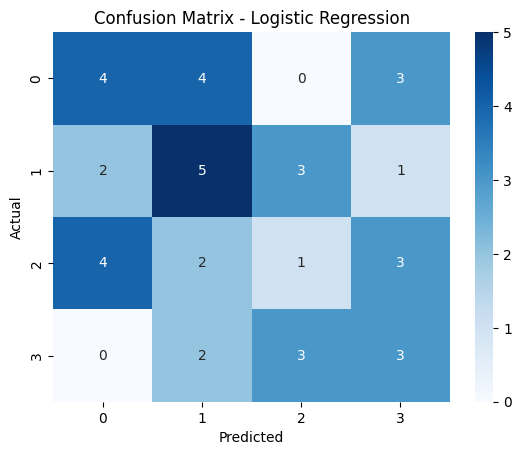

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()